# L5. Lab: Your Smartphone Assistant

A day of photos, a voice note, and text notes all land in one `EdgeShard`. Later you ask it things, and it answers offline, including a coffee-place note from L2.

## 1. A day's captures

In [1]:
from pathlib import Path

BASE = 1_699_920_000  # "today 00:00 UTC"
def at(h): return BASE + int(h * 3600)

voice_transcript = Path("../data/voice_note.txt").read_text().strip()

captures = [
    # photos (image vector via CLIP)
    {"source_type": "photo", "file": "coffee.jpg",
     "timestamp": at(8.2), "location": "5th St",
     "category": "food", "store": "Blue Cup"},
    {"source_type": "photo", "file": "restaurant.jpg",
     "timestamp": at(13.0), "location": "Downtown",
     "category": "food", "store": "Ramen-ya"},
    {"source_type": "photo", "file": "sneakers.jpg",
     "timestamp": at(15.3), "location": "Mall",
     "category": "shoes", "store": "SportsWorld",
     "price": 45.0},
    {"source_type": "photo", "file": "street.jpg",
     "timestamp": at(16.0), "location": "Mall",
     "category": "travel"},
    {"source_type": "photo", "file": "plant.jpg",
     "timestamp": at(17.5), "location": "Home",
     "category": "home"},
    # voice note (text vector via Nomic): transcript of
    # on-device Whisper
    {"source_type": "voice", "transcript": voice_transcript,
     "timestamp": at(13.4), "location": "Downtown",
     "category": "food", "store": "Ramen-ya",
     "price": 14.0},
    # text notes (text vector via Nomic)
    {"source_type": "text",
     "note": "Great little coffee place on 5th with "
             "outdoor seating and fast wifi",
     "timestamp": at(8.3), "location": "5th St",
     "category": "food"},
    {"source_type": "text",
     "note": "Standup with Sarah moved to Thursday to "
             "review the Q3 roadmap",
     "timestamp": at(10.0), "location": "Office",
     "category": "work"},
]
print(len(captures), "memories captured across",
     len({c["source_type"] for c in captures}), "modalities")

8 memories captured across 3 modalities


## 2. One shard for the whole day

In [2]:
from helper import (create_memory_shard, add_memories,
                   embed_text, embed_image,
                   NOMIC_DIM, CLIP_DIM)
from qdrant_edge import UpdateOperation, PayloadSchemaType

shard = create_memory_shard(
    "./day_shard", {"text": NOMIC_DIM, "image": CLIP_DIM})

texts = [c for c in captures if c["source_type"] in ("text", "voice")]
photos = [c for c in captures if c["source_type"] == "photo"]

add_memories(shard, "text",
            embed_text([c.get("note") or c["transcript"]
                       for c in texts]),
            texts, start_id=0, optimize=False)
add_memories(shard, "image",
             embed_image([f"../data/images/{c['file']}"
                         for c in photos]),
             photos, start_id=100, optimize=False)

for field, kind in [("category", PayloadSchemaType.Keyword),
                    ("location", PayloadSchemaType.Keyword),
                    ("timestamp", PayloadSchemaType.Float),
                    ("price", PayloadSchemaType.Float)]:
    shard.update(UpdateOperation.create_field_index(field, kind))
shard.optimize()
print("Day stored in one shard")

Day stored in one shard


## 3. Money output: the day, on a timeline

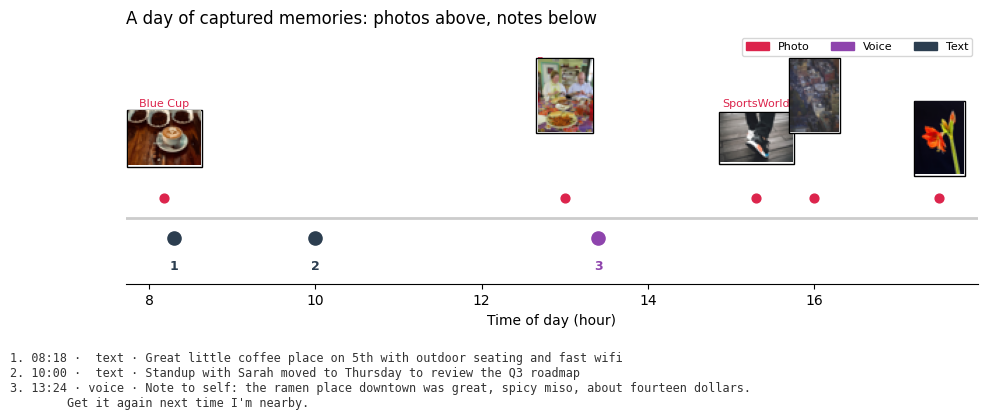

In [3]:
from helper import day_timeline
day_timeline(captures, "../data/images")

## 4. How recall works here

In [4]:
from helper import search_memories, embed_query, embed_text_clip

def recall(semantic_query, query_filter=None, limit=3):
    text_hits = search_memories(
        shard, "text", embed_query(semantic_query),
        limit=limit, query_filter=query_filter)
    image_hits = search_memories(
        shard, "image", embed_text_clip(semantic_query),
        limit=limit, query_filter=query_filter)
    return {
        "Photos": image_hits,
        "Voice Notes": [h for h in text_hits
                       if h.payload.get("source_type") == "voice"],
        "Text Notes": [h for h in text_hits
                      if h.payload.get("source_type") == "text"],
    }

print("routing: text -> Voice Notes / Text Notes ; "
     "image -> Photos ; scores kept separate")

routing: text -> Voice Notes / Text Notes ; image -> Photos ; scores kept separate


## 5. One moment, two ways to find it

In [5]:
from qdrant_edge import Point, UpdateOperation

# The coffee photo was reachable only through the image
# (CLIP) space. Re-upsert the SAME id with both an image
# vector and a text caption: one moment, two doors.
# Both vectors go in one upsert; omit either and Edge drops it.
caption = "a latte in a blue cup on an outdoor cafe table"
coffee = next(c for c in photos if c["file"] == "coffee.jpg")
shard.update(UpdateOperation.upsert_points([Point(
    id=100,
    vector={"image": embed_image(["../data/images/coffee.jpg"])[0],
            "text":  embed_text([caption])[0]},
    payload={**coffee, "caption": caption},
)]))
shard.optimize()

# Same moment, found two ways: by picture (CLIP) and now
# by words (Nomic).
q = "latte in a blue cup"
by_image = search_memories(
    shard, "image", embed_text_clip(q), limit=1)[0]
by_text = search_memories(
    shard, "text", embed_query(q), limit=1)[0]
print("image space ->", by_image.id, by_image.payload["store"])
print("text  space ->", by_text.id, by_text.payload.get("caption"))

image space -> 100 Blue Cup
text  space -> 100 a latte in a blue cup on an outdoor cafe table


## 6. Money output: "black and white sneakers under \$50"

semantic_query,"""black and white sneakers"""
filters,category = shoes AND price < 50
search_space,text (Nomic) + image (CLIP)



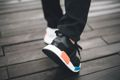

In [6]:
from helper import query_contract, memory_inbox, all_of, match, numeric
from IPython.display import display

shoes_filter = all_of(
    match("category", "shoes"), numeric("price", lt=50))
display(query_contract("black and white sneakers",
                       "category = shoes AND price < 50",
                       "text (Nomic) + image (CLIP)"))
memory_inbox(recall("black and white sneakers", shoes_filter),
            "../data/images")

## 7. Money output: "coffee place with outdoor seating, this morning"

semantic_query,"""coffee place with outdoor seating"""
filters,timestamp in 06:00-12:00 AND location = 5th St
search_space,text (Nomic) + image (CLIP)



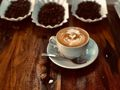

In [7]:
from helper import time_window

morning = all_of(
    time_window(at(6), at(12)), match("location", "5th St"))
display(query_contract("coffee place with outdoor seating",
                       "timestamp in 06:00-12:00 AND location = 5th St",
                       "text (Nomic) + image (CLIP)"))
memory_inbox(recall("coffee place with outdoor seating", morning),
            "../data/images")

## 8. Money output: correct a memory in place

In [8]:
from helper import count_memories

# The patio closed. Re-embed the corrected note and upsert
# it under the SAME point id (1) as the original coffee
# note: this overwrites, it does not append.
corrected = {"source_type": "text",
            "note": "Blue Cup coffee on 5th St: the outdoor "
                    "seating closed for winter, but the wifi "
                    "is still fast",
            "timestamp": at(8.3), "location": "5th St",
            "category": "food"}
add_memories(shard, "text", embed_text([corrected["note"]]),
            [corrected], start_id=1)

after = recall("coffee place with outdoor seating",
              morning)["Text Notes"][0].payload["note"]
print("memories:", count_memories(shard), "(unchanged)")
print("recall now:", after)

memories: 8 (unchanged)
recall now: Blue Cup coffee on 5th St: the outdoor seating closed for winter, but the wifi is still fast


## 9. Money output: "where did I have lunch?"

semantic_query,"""a good bowl of ramen for lunch"""
filters,category = food
search_space,text (Nomic) + image (CLIP)



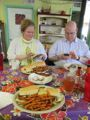
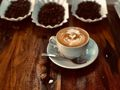

In [9]:
display(query_contract("a good bowl of ramen for lunch",
                       "category = food",
                       "text (Nomic) + image (CLIP)"))
memory_inbox(recall("a good bowl of ramen for lunch",
                    all_of(match("category", "food"))),
            "../data/images", min_score=0.55)

## 10. Money output: it's all still there tomorrow

⚠ Network disabled for this cell


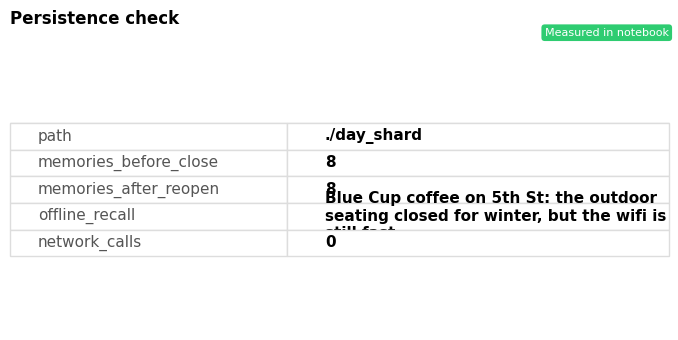

In [10]:
from helper import (count_memories, reopen_shard,
                   no_network, receipt_table)

before = count_memories(shard)
shard.close()
with no_network():
    shard = reopen_shard("./day_shard")
    check = recall("coffee place with outdoor seating",
                   all_of(time_window(at(6), at(12))))

receipt_table([
    ("path", "./day_shard"),
    ("memories_before_close", before),
    ("memories_after_reopen", count_memories(shard)),
    ("offline_recall", check["Text Notes"][0].payload["note"]),
    ("network_calls", 0),
], title="Persistence check")

In [11]:
# Close the shard but keep it on disk: L6 reopens this
# same phone memory.
shard.close()
print("Shard closed and kept at ./day_shard (L6 reads it back)")

Shard closed and kept at ./day_shard (L6 reads it back)
